# Visualizing different water percolation schemes

Q: What is sensitivity of the runoff line if runoff begins to be generated at the pore-close-off density and is responsive to ice lens?

`test_runoff_830_k_transect_line` --> runoff increased linearly when density exceeds 830

`test_ice_lens_runoff_k_transect_line` --> runoff sensitive to ice lenses

`test_both_runoff_k_transect_line` --> both conditions implemented


In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
#Dependencies

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from pathlib import Path
from firn_analysis import compute_firn_ice_content_column, compute_firn_thickness_column, compute_t10m_column
import config
import os

from datetime import datetime as _dt, timedelta as _td
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches

In [67]:
from datetime import datetime as _dt, timedelta as _td
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches


def _datetime_to_frac_year(dt):
    """Convert a datetime to fractional year (e.g. 1939.666...)."""
    yr = dt.year
    s = _dt(yr, 1, 1)
    e = _dt(yr + 1, 1, 1)
    return yr + (dt - s).total_seconds() / (e - s).total_seconds()


def build_time_axes(data_dir):
    """
    Build fractional-year time axes for 1D (daily) and 2D (monthly) output files.

    Returns
    -------
    time_1d : np.ndarray  shape (n_days,)
    time_2d : np.ndarray  shape (n_monthly,)
    """
    output_dir = Path(data_dir) / 'output'

    sample_1d = next(output_dir.glob('*_1D_*.nc'), None)
    sample_2d = next((f for f in output_dir.glob('*_2D_*.nc')
                      if '2Ddetail' not in f.name), None)

    if sample_1d is None:
        raise FileNotFoundError(f'No 1D output files found in {output_dir}')

    def _read_meta(path, default_dt):
        with xr.open_dataset(path, decode_times=False) as ds:
            start = _dt.fromisoformat(
                ds.attrs['model_start_datetime'].replace('T', ' ').split('.')[0])
            dt = int(ds.attrs.get('timestep_length_of_dimension_in_seconds', default_dt))
            t_dim = next(d for d in ds.sizes if 'ind_t' in d or 'time' in d.lower())
            n = ds.sizes[t_dim]
        return start, dt, n

    start, dt_1d, n_1d = _read_meta(sample_1d, 86400)

    dt_2d, n_2d = 2592000, None
    if sample_2d is not None:
        _, dt_2d, n_2d = _read_meta(sample_2d, 2592000)

    def _make_axis(dt_seconds, n):
        step = _td(seconds=dt_seconds)
        return np.array([_datetime_to_frac_year(start + step * i) for i in range(n)])

    return _make_axis(dt_1d, n_1d), _make_axis(dt_2d, n_2d)


def _layer_thicknesses(depth):
    """
    Compute layer thicknesses from the cumulative depth array.

    Convention: layer 0 is deepest (depth[0] ≈ 122 m), layer -1 is surface
    (depth[-1] ≈ small).  Layer l spans from depth[l+1] (top) to depth[l]
    (bottom), so dz[l] = depth[l] - depth[l+1].  The surface layer has top at 0.

    Parameters
    ----------
    depth : np.ndarray  shape (n_layers, n_t)  — cumulative depth from surface (m)

    Returns
    -------
    dz : np.ndarray  shape (n_layers, n_t)  — layer thicknesses (m), all >= 0
    """
    # Append a zero row for the surface (top of the surface layer)
    depth_with_surface = np.concatenate([depth, np.zeros((1, depth.shape[1]))], axis=0)
    dz = np.diff(depth_with_surface, axis=0) * -1   # depth decreases towards surface
    return np.abs(dz)                                # guard against sign surprises


def compute_ice_fraction_20m_column(fpath_2d, max_depth=20.0, ice_dens_threshold=830.0):
    """
    Ice volume fraction in the upper `max_depth` m at each 2D timestep.

        fraction (%) = sum(dz for ice layers with depth < max_depth)
                     / sum(dz for all layers with depth < max_depth)  × 100

    Both sums use actual Lagrangian layer thicknesses derived from the depth array,
    so the denominator is the total zone thickness (ice + firn), not firn alone.

    Returns
    -------
    frac_20m : np.ndarray shape (n_t,)  — NaN where the zone contains no layers
    """
    with xr.open_dataset(fpath_2d, decode_times=False) as ds:
        dens  = ds['dens'].values    # (n_layers, n_t)
        depth = ds['depth'].values   # (n_layers, n_t), cumulative depth from surface (m)

    dz = _layer_thicknesses(depth)         # (n_layers, n_t)

    in_upper = depth < max_depth           # select layers whose bottom is within the zone
    is_ice   = dens > ice_dens_threshold

    dz_ice = np.where(in_upper & is_ice, dz, 0.0)
    dz_all = np.where(in_upper,          dz, 0.0)

    ice_sum = dz_ice.sum(axis=0)           # (n_t,)
    all_sum = dz_all.sum(axis=0)

    with np.errstate(all='ignore'):
        return np.where(all_sum > 0, ice_sum / all_sum * 100.0, np.nan)


def compute_ice_age_column(fpath_2d, time_arr, ice_dens_threshold=830.0, max_depth=20.0):
    """
    Mean age (years) of ice-density layers in the upper `max_depth` m, at each 2D timestep.

    Age is only computed where firn exists; all-ice timesteps return NaN without warning.

    Returns
    -------
    ice_age : np.ndarray shape (n_t,)
    """
    ICE_DENSITY = 917.0
    time_sim = time_arr - time_arr[0]
    with xr.open_dataset(fpath_2d, decode_times=False) as ds:
        dens  = ds['dens'].values
        depth = ds['depth'].values
        year  = ds['year'].values

    n_t = dens.shape[1]
    has_firn = np.any(dens < ICE_DENSITY, axis=0)

    valid    = (depth < max_depth) & (dens > ice_dens_threshold) & (year >= 0)
    ages_raw = time_sim[np.newaxis, :] - year
    ages     = np.where(valid & (ages_raw >= 0), ages_raw, np.nan)

    result = np.full(n_t, np.nan)
    if has_firn.any():
        result[has_firn] = np.nanmean(ages[:, has_firn], axis=0)
    return result


def get_ice_content(DATA_DIR, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH,
                    RERUN=False, TITLE="", compute_ice_age=True, runoff_limit=10):
    """
    Compute per-column firn diagnostics for all transect points.

    Variables saved to OUTPUT_FILEPATH:
      firn_ice_content   — integrated ice mass in full firn column (kg m⁻²)
      firn_thickness     — total firn thickness, full column (m)
      ice_fraction_20m   — ice volume fraction in top 20 m (%), derived from layer dz
      ice_age            — mean age of ice-density layers in top 20 m (yr) [if compute_ice_age]
      runoff_limit_lon   — highest longitude with Runoff > 0 per 30-day window
      runoff_monthly     — total runoff per 30-day window per column (mm w.e.)
      t10m               — temperature at 10 m depth per column (°C)
      runoff_limit       - minimum threshold for mm w.e. production per 30-day window

    Parameters
    ----------
    compute_ice_age : bool
        If True (default), compute mean ice age from 2D files (slower).
        Mode='age' in hovmoller_ice_plot requires this.
    """
    time_1d_arr, time_arr = build_time_axes(DATA_DIR)
    n_2d   = len(time_arr)
    n_1d   = len(time_1d_arr)
    days_per_window = n_1d // n_2d

    file_nums = [int(l) for l in POINTLIST.read_text().split() if l.strip()]
    ref    = pd.read_csv(REF_POINTLIST, header=None, sep=',',
                            names=['lon', 'lat', 'c2', 'c3', 'c4', 'rlat_idx', 'rlon_idx'],
                            skipinitialspace=True)

    if OUTPUT_FILEPATH.exists() and not RERUN:
        ds = xr.open_dataset(OUTPUT_FILEPATH)
        print(f'Loaded file from {OUTPUT_FILEPATH}')
    else:
        fic_all, fth_all, frac_all, ice_age_all, runoff_all, fac_all, t10m_all = [], [], [], [], [], [], []
        file_nums_ok, lons_ok_list, errors = [], [], []

        for fn in file_nums:
            fpath_2d = DATA_DIR / 'output' / f'FGRN055_era055_2D_{fn}.nc'
            fpath_1d = DATA_DIR / 'output' / f'FGRN055_era055_1D_{fn}.nc'
            if not fpath_2d.exists():
                errors.append(fn); continue
            try:
                fic_all.append(compute_firn_ice_content_column(fpath_2d))
                fth_all.append(compute_firn_thickness_column(fpath_2d))
                frac_all.append(compute_ice_fraction_20m_column(fpath_2d))
                if compute_ice_age:
                    ice_age_all.append(compute_ice_age_column(fpath_2d, time_arr))
                t10m_all.append(compute_t10m_column(fpath_2d))
                file_nums_ok.append(fn)
                lons_ok_list.append(ref.iloc[fn - 1]['lon'])
                if fpath_1d.exists():
                    with xr.open_dataset(fpath_1d, decode_times=False) as ds1d:
                        runoff_all.append(ds1d['Runoff'].values)
                        fac_all.append(ds1d['FirnAir'].values)
                else:
                    runoff_all.append(np.zeros(n_1d))
                    fac_all.append(np.zeros(n_1d))
            except Exception as e:
                print(f'  ERROR file {fn}: {e}')
                errors.append(fn)

        fic_arr     = np.array(fic_all)
        fth_arr     = np.array(fth_all)
        frac_arr    = np.array(frac_all)
        runoff_arr  = np.array(runoff_all)
        fac_arr     = np.array(fac_all)
        t10m_arr    = np.array(t10m_all)

        # Per-year, per-column: was FAC == 0 at any daily step in that year?
        years_1d_int  = np.floor(time_1d_arr).astype(int)
        years_2d_int  = np.floor(time_arr).astype(int)
        fac_zero_2d   = np.zeros((len(fac_arr), n_2d), dtype=bool)
        for yr in np.unique(years_2d_int):
            t1d = years_1d_int == yr
            t2d = years_2d_int == yr
            if t1d.any():
                fac_zero_2d[:, t2d] = np.any(fac_arr[:, t1d] == 0.0, axis=1)[:, np.newaxis]
        lons_ok_arr = np.array(lons_ok_list)
        pts_ok = ref.iloc[[fn - 1 for fn in file_nums_ok]].reset_index(drop=True)
        print(f'Processed {len(fic_arr)}/{len(file_nums)} columns  ({len(errors)} errors)')

        runoff_limit_lon = np.full(n_2d, np.nan)
        runoff_monthly_arr = np.zeros((len(runoff_arr), n_2d), dtype=np.float32)
        for i in range(n_2d):
            s, e = i * days_per_window, min((i + 1) * days_per_window, n_1d)
            window_total = runoff_arr[:, s:e].sum(axis=1)
            mask = window_total >= runoff_limit  # minimum 10 mm w.e. per 30-day window
            if mask.any():
                runoff_limit_lon[i] = lons_ok_arr[mask].max()
            runoff_monthly_arr[:, i] = window_total

        data_vars = {
            'firn_ice_content': xr.DataArray(
                fic_arr, dims=('point', 'time'),
                attrs={'long_name': 'Integrated firn ice content', 'units': 'kg m-2'}),
            'firn_thickness': xr.DataArray(
                fth_arr, dims=('point', 'time'),
                attrs={'long_name': 'Total firn thickness', 'units': 'm'}),
            'ice_fraction_20m': xr.DataArray(
                frac_arr, dims=('point', 'time'),
                attrs={'long_name': 'Ice volume fraction in top 20 m',
                       'units': '%',
                       'description': 'sum(dz_ice) / sum(dz_all) × 100 for layers with depth < 20 m'}),
            'runoff_limit_lon': xr.DataArray(
                runoff_limit_lon, dims=('time',),
                attrs={'long_name': 'Runoff limit longitude', 'units': 'degrees_east'}),
            'runoff_monthly': xr.DataArray(
                runoff_monthly_arr, dims=('point', 'time'),
                attrs={'long_name': 'Total runoff per 30-day window', 'units': 'mm w.e.',
                       'description': 'Sum of daily Runoff over each 30-day window per column'}),
            't10m': xr.DataArray(
                t10m_arr, dims=('point', 'time'),
                attrs={'long_name': 'Firn temperature at 10 m depth', 'units': 'degC'}),
            'fac_ever_zero': xr.DataArray(
                fac_zero_2d, dims=('point', 'time'),
                attrs={'long_name': 'FAC zero in any daily step this year',
                       'description': 'True if FirnAir==0 at any daily timestep in the calendar year'}),
        }
        if compute_ice_age and ice_age_all:
            data_vars['ice_age'] = xr.DataArray(
                np.array(ice_age_all), dims=('point', 'time'),
                attrs={'long_name': 'Mean age of ice-density layers in upper 20 m',
                       'units': 'years', 'ice_dens_threshold_kg_m3': 830.0})

        ds = xr.Dataset(
            data_vars,
            coords={
                'time':      xr.DataArray(time_arr,
                                 attrs={'long_name': 'time', 'units': 'fractional calendar year'}),
                'point_num': xr.DataArray(np.array(file_nums_ok, dtype=np.int32), dims=('point',),
                                 attrs={'long_name': '1-based file number in master pointlist'}),
                'lon':       xr.DataArray(pts_ok['lon'].values, dims=('point',),
                                 attrs={'units': 'degrees_east'}),
                'lat':       xr.DataArray(pts_ok['lat'].values, dims=('point',),
                                 attrs={'units': 'degrees_north'}),
            },
            attrs={'title': TITLE, 'source': 'firn_analysis.compute_firn_ice_content_column'},
        )
        OUTPUT_FILEPATH.unlink(missing_ok=True)
        ds.to_netcdf(OUTPUT_FILEPATH)
        print(f'Saved: {OUTPUT_FILEPATH}')

    return ds


# ── Hovmöller helpers ─────────────────────────────────────────────────────────

def _build_disp_var(ds, mode, lon_sort):
    """Compute the display variable, cmap and labels for one Hovmöller mode."""
    fic_all = ds['firn_ice_content'].values

    if mode == 'mass':
        disp       = (fic_all / 1000.0)[lon_sort]   # m w.e.
        cbar_label = 'FIC (m w.e.)'
        cmap       = 'YlOrRd'

    elif mode == 'fraction':
        if 'ice_fraction_20m' not in ds:
            raise ValueError(
                "'ice_fraction_20m' not found. Re-run get_ice_content() with RERUN=True.")
        disp       = ds['ice_fraction_20m'].values[lon_sort]   # %
        cbar_label = 'Ice vol. fraction top 20 m (%)'
        cmap       = 'plasma'

    elif mode == 'age':
        if 'ice_age' not in ds:
            raise ValueError(
                "'ice_age' not found. Re-run get_ice_content() with compute_ice_age=True and RERUN=True.")
        disp       = ds['ice_age'].values[lon_sort]   # years
        cbar_label = 'Mean ice age (yr)'
        cmap       = 'cividis'

    else:
        raise ValueError(f"Unknown mode '{mode}'. Choose 'mass', 'fraction', 'age', or 'all'.")

    return disp, cbar_label, cmap


def _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                          cmap, cbar_label, annual_peak_lons, annual_peak_times,
                          title='', fontsize=14):
    """Draw a single Hovmöller panel onto `ax`."""
    ax.set_facecolor('#add8e6')  # light blue = all ice / no firn

    # Variable colourmap (ice-covered cells only)
    disp_masked = np.where(has_ice, disp, np.nan)
    finite_vals = disp_masked[np.isfinite(disp_masked)]
    vmax = max(np.nanpercentile(finite_vals, 95) if finite_vals.size else 1.0, 0.01)
    pcm_var = ax.pcolormesh(lons_s, time_arr, disp_masked.T,
                            cmap=cmap, vmin=0, vmax=vmax, shading='nearest')
    cb_var = plt.colorbar(pcm_var, ax=ax, shrink=0.8, pad=0.01)
    cb_var.set_label(cbar_label, fontsize=fontsize)

    ax.scatter(annual_peak_lons, annual_peak_times, s=15, color='hotpink', zorder=7)
    ax.legend(handles=[
        mpatches.Patch(color='#add8e6', label='All ice / no firn'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='hotpink',
                   markersize=5, label='Annual peak runoff limit'),
    ], loc='lower right', fontsize=fontsize - 3, framealpha=0.85)
    ax.set_xlabel('Longitude (°E)', fontsize=fontsize)
    ax.set_ylabel('Year', fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1)
    ax.tick_params(labelsize=fontsize - 1)
    ax.invert_yaxis()


def hovmoller_ice_plot(ds, mode='mass'):
    """
    Hovmöller plot(s) of firn ice content along the K-transect.

    Parameters
    ----------
    ds : xr.Dataset from get_ice_content()
    mode : str
        'mass'     — firn ice content (m w.e.)  [default]
        'fraction' — ice volume fraction (%) in top 20 m
                     = sum(dz_ice) / sum(dz_ice + dz_firn) × 100
                     (requires 'ice_fraction_20m'; rerun get_ice_content with RERUN=True)
        'age'      — mean age (yr) of ice-density layers in top 20 m
                     (requires 'ice_age'; rerun get_ice_content with compute_ice_age=True)
        'all'      — three-panel Hovmöller: mass, fraction, age side-by-side (no time-mean panel)
    """
    fic_all  = ds['firn_ice_content'].values
    fth_all  = ds['firn_thickness'].values
    time_arr = ds['time'].values
    rl_lon   = ds['runoff_limit_lon'].values
    lons_ok  = ds['lon'].values
    title    = ds.attrs.get('title', '')

    lon_sort = np.argsort(lons_ok)
    lons_s   = lons_ok[lon_sort]
    fic_s    = (fic_all / 1000.0)[lon_sort]
    fth_s    = fth_all[lon_sort]
    has_ice  = fic_s > 0

    years_int = np.floor(time_arr).astype(int)
    annual_peak_lons, annual_peak_times = [], []
    for yr in np.unique(years_int):
        mask = years_int == yr
        if np.any(np.isfinite(rl_lon[mask])):
            annual_peak_lons.append(np.nanmax(rl_lon[mask]))
            annual_peak_times.append(time_arr[np.where(mask)[0][-1]])
    annual_peak_lons  = np.array(annual_peak_lons)
    annual_peak_times = np.array(annual_peak_times)

    # ── mode='all': three Hovmöller panels, no time-mean ─────────────────────
    if mode == 'all':
        fig, axes = plt.subplots(1, 3, figsize=(21, 7))
        for ax, m in zip(axes, ('mass', 'fraction', 'age')):
            disp, cbar_label, cmap = _build_disp_var(ds, m, lon_sort)
            _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                                  cmap, cbar_label,
                                  annual_peak_lons, annual_peak_times,
                                  title=f'{title}  —  {m}')
        plt.tight_layout()
        plt.show()
        return

    # ── single mode: Hovmöller (left) + time-mean (right) ────────────────────
    disp, cbar_label, cmap = _build_disp_var(ds, mode, lon_sort)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    _draw_hovmoller_panel(axes[0], lons_s, time_arr, fth_s, disp, has_ice,
                          cmap, cbar_label,
                          annual_peak_lons, annual_peak_times,
                          title=f'{title}\n{cbar_label} along K-transect')

    ax2 = axes[1]
    with np.errstate(all='ignore'):
        disp_mean = np.nanmean(disp, axis=1)
    nan_frac = np.isnan(fic_s).mean(axis=1)
    fth_mean = np.nanmean(fth_s, axis=1)

    ax2b = ax2.twinx()
    ax2b.fill_between(lons_s, nan_frac, alpha=0.2, color='grey',
                      label='Fraction all-ice (NaN)')
    fth_norm = fth_mean / fth_mean[np.nanargmax(fth_mean)] if np.any(np.isfinite(fth_mean)) else fth_mean
    ax2b.plot(lons_s, fth_norm, '--', color='steelblue', lw=1.2,
              label='Mean firn thickness (norm.)')
    ax2b.set_ylabel('Fraction / normalised thickness', fontsize=10, color='grey')
    ax2b.set_ylim(0, 1.2)

    ax2.plot(lons_s, disp_mean, 'o-', color='firebrick', ms=4, zorder=5,
             label=f'Time-mean {cbar_label}')

    if len(annual_peak_lons) > 0:
        trans = blended_transform_factory(ax2.transData, ax2.transAxes)
        ax2.plot(annual_peak_lons, np.zeros(len(annual_peak_lons)), '|',
                 transform=trans, ms=12, mew=1.5, color='hotpink', alpha=0.8,
                 zorder=7, label='Annual peak runoff limit')

    ax2.set_xlabel('Longitude (°E)', fontsize=11)
    ax2.set_ylabel(f'Time-mean {cbar_label}', fontsize=11)
    ax2.set_title(f'Time-mean {cbar_label} vs longitude', fontsize=11)
    ax2.grid(True, alpha=0.3)

    lines1, labs1 = ax2.get_legend_handles_labels()
    lines2, labs2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper left')

    plt.tight_layout()
    plt.show()

def plot_density_profile_vs_longitude(DATA_DIR, POINTLIST, REF_POINTLIST,
                                       time_target=None, date_range=None,
                                       max_depth=20.0, n_depth=200,
                                       cmap='viridis', figsize=(12, 6), title=''):
    """
    Cross-section plot: firn density (colour) vs depth (y-axis) and longitude (x-axis).
    Uses 2Ddetail files (4 cm layers, top 20 m, 10-day steps).

    Parameters
    ----------
    time_target : float or None
        Fractional year for a snapshot (nearest 2Ddetail timestep used).
        If both time_target and date_range are None, averages over all time.
    date_range : tuple ('YYYY-MM-DD', 'YYYY-MM-DD') or None
        Average density over this time window (overrides time_target).
    max_depth : float   — maximum depth to display (m)
    n_depth : int       — number of levels in the interpolated depth grid
    cmap : str          — colormap for density (default 'viridis'; try 'Blues' or 'plasma')

    Example
    -------
    # Snapshot near the 2012 melt season peak:
    plot_density_profile_vs_longitude(DATA_DIR_baseline, POINTLIST, REF_POINTLIST,
                                       time_target=2012.6, title='Baseline')

    # Time-mean over a decade:
    plot_density_profile_vs_longitude(DATA_DIR_baseline, POINTLIST, REF_POINTLIST,
                                       date_range=('2010-01-01', '2020-12-31'))
    """
    from scipy.interpolate import interp1d

    output_dir = Path(DATA_DIR) / 'output'
    file_nums  = [int(l) for l in POINTLIST.read_text().split() if l.strip()]
    ref = pd.read_csv(REF_POINTLIST, header=None, sep=',',
                      names=['lon', 'lat', 'c2', 'c3', 'c4', 'rlat_idx', 'rlon_idx'],
                      skipinitialspace=True)

    # Build 2Ddetail time axis from a sample file
    sample = next(output_dir.glob('*_2Ddetail_*.nc'), None)
    if sample is None:
        raise FileNotFoundError(f'No 2Ddetail files found in {output_dir}')
    with xr.open_dataset(sample, decode_times=False) as ds_s:
        start_str = ds_s.attrs['model_start_datetime'].replace('T', ' ').split('.')[0]
        start  = _dt.fromisoformat(start_str)
        dt_s   = int(ds_s.attrs.get('timestep_length_of_dimension_in_seconds', 864000))
        t_dim  = next(d for d in ds_s.sizes if 'ind_t' in d or 'time' in d.lower())
        n_t    = ds_s.sizes[t_dim]
    time_2dd = np.array([_datetime_to_frac_year(start + _td(seconds=dt_s * i))
                         for i in range(n_t)])

    # Determine which timestep indices to use
    if date_range is not None:
        t0 = _datetime_to_frac_year(_dt.strptime(date_range[0], '%Y-%m-%d'))
        t1 = _datetime_to_frac_year(_dt.strptime(date_range[1], '%Y-%m-%d'))
        t_indices = np.where((time_2dd >= t0) & (time_2dd <= t1))[0]
        if t_indices.size == 0:
            raise ValueError('No 2Ddetail timesteps fall within the specified date_range.')
        plot_title_time = f'{date_range[0]} – {date_range[1]} (time mean)'
    elif time_target is not None:
        t_indices = np.array([int(np.argmin(np.abs(time_2dd - time_target)))])
        plot_title_time = f'{time_target:.3f}'
    else:
        t_indices = np.arange(n_t)
        plot_title_time = 'time mean'

    # Common depth grid (surface to max_depth, positive downward)
    depth_grid = np.linspace(0.02, max_depth, n_depth)

    dens_profiles, lons_ok = [], []
    for fn in file_nums:
        fpath = output_dir / f'FGRN055_era055_2Ddetail_{fn}.nc'
        if not fpath.exists():
            continue
        try:
            with xr.open_dataset(fpath, decode_times=False) as ds2d:
                dens_nc  = ds2d['dens'].values    # (layer, n_t)
                depth_nc = ds2d['depth'].values   # (layer, n_t) or (layer,) if time-invariant

            # Some columns store depth as 1-D (time-invariant); broadcast to 2-D
            if depth_nc.ndim == 1:
                depth_nc = np.broadcast_to(depth_nc[:, np.newaxis], dens_nc.shape)

            # For each selected timestep, interpolate profile onto common depth grid
            profiles = []
            for ti in t_indices:
                d = depth_nc[:, ti]
                r = dens_nc[:, ti]
                order = np.argsort(d)             # ensure monotone increasing depth
                d, r  = d[order], r[order]
                keep  = d <= max_depth * 1.05     # small margin for edge layers
                if keep.sum() < 2:
                    profiles.append(np.full(n_depth, np.nan))
                    continue
                f = interp1d(d[keep], r[keep], kind='linear',
                             bounds_error=False, fill_value=np.nan)
                profiles.append(f(depth_grid))

            dens_profiles.append(np.nanmean(profiles, axis=0))
            lons_ok.append(ref.iloc[fn - 1]['lon'])
        except Exception as e:
            print(f'  ERROR file {fn}: {e}')

    if not dens_profiles:
        print('No profiles loaded — check that 2Ddetail files exist in the output dir.')
        return

    lons_ok  = np.array(lons_ok)
    lon_sort = np.argsort(lons_ok)
    dens_grid   = np.array(dens_profiles)[lon_sort]   # (n_pts, n_depth)
    lons_sorted = lons_ok[lon_sort]

    fig, ax = plt.subplots(figsize=figsize)
    pcm = ax.pcolormesh(lons_sorted, depth_grid, dens_grid.T,
                        cmap=cmap, shading='nearest', vmin=300, vmax=917)
    cb = plt.colorbar(pcm, ax=ax)
    cb.set_label('Density (kg m⁻³)', fontsize=11)

    ax.set_xlabel('Longitude (°E)', fontsize=11)
    ax.set_ylabel('Depth (m)', fontsize=11)
    hdr = f'{title}  ' if title else ''
    ax.set_title(f'{hdr}Firn density cross-section  [{plot_title_time}]', fontsize=12)
    ax.invert_yaxis()   # depth increases downward
    plt.tight_layout()
    plt.show()


# Reference longitudes from Machguth et al. 2026 (doi:10.5194/tc-20-427-2026)
# Converted from m a.s.l. → longitude via FGRN055 K-transect topographic profile.
#
# Paper-reported MODIS mean ± 1 SD (2000–2021, western Greenland):
#   1613 ± 99 m a.s.l.  →  mean = -48.183°E,  range -48.423 to -47.957°E
#
# Per-year MODIS annual-mean runoff limit (Zenodo:18248869,
#   __GR_table_simple_annual_max_SL.xlsx, converted from elevation):
_MACHGUTH2026 = {
    'modis_mean': -48.183,   # paper-reported 2000-2021 mean (1613 m a.s.l.)
    'modis_min':  -48.423,   # mean − 1 SD  (1514 m)
    'modis_max':  -47.957,   # mean + 1 SD  (1712 m)
    'fdm_mean':   -48.348,   # IMAU-FDM mean (1545 m a.s.l., Machguth+2026)
    # MAR K-transect (flowline 160) — Greenland-wide ±94 m mapped to K-transect topo
    'mar_ktransect_mean': -46.919,  # 1816 m a.s.l.
    'mar_ktransect_min':  -47.322,  # 1722 m  (mean − 1 SD)
    'mar_ktransect_max':  -46.518,  # 1910 m  (mean + 1 SD)
    # Annual MODIS values for K-transect flowline 160 (67.065°N ≈ KAN_M)
    # Source: Zenodo:18248869, __GR_table_simple_annual_max_SL.xlsx
    # Converted from elevation (m a.s.l.) via FGRN055 topographic profile
    'annual_years': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                     2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                     2020, 2021],
    'annual_lons':  [-48.031, -48.073, -48.182, -48.022, -47.984, -47.984, -48.031,
                     -47.939, -48.031, -48.031, -47.516, -47.874, -47.453, -47.883,
                     -47.831, -47.880, -47.699, -48.154, -47.939, -47.699, -48.063,
                     -47.831],
    # K-transect flowline 160 stats (2000-2021)
    'modis_ktransect_mean': -47.938,   # 1720.6 m a.s.l.
    'modis_ktransect_min':  -48.182,   # 1613 m  (2002)
    'modis_ktransect_max':  -47.453,   # 1852 m  (2012)
}


def hovmoller_four_panel(datasets, mode='mass', figsize=(22, 16)):
    """
    Plot the Hovmöller panel for four datasets in a 2×2 grid.

    Parameters
    ----------
    datasets : dict  {label: xr.Dataset}
        E.g. {'Baseline': ds_baseline, 'Ice lens': ds_icelens,
               '830 density': ds_dens830, 'Both': ds_both}
        Order is preserved (dict insertion order, Python 3.7+).
    mode : str
        'mass' | 'fraction' | 'age'  — same as hovmoller_ice_plot
    figsize : tuple
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)

    for ax, (label, ds) in zip(axes.flat, datasets.items()):
        fic_all  = ds['firn_ice_content'].values
        fth_all  = ds['firn_thickness'].values
        time_arr = ds['time'].values
        rl_lon   = ds['runoff_limit_lon'].values
        lons_ok  = ds['lon'].values

        lon_sort = np.argsort(lons_ok)
        lons_s   = lons_ok[lon_sort]
        fic_s    = (fic_all / 1000.0)[lon_sort]
        fth_s    = fth_all[lon_sort]
        has_ice  = fic_s > 0

        years_int = np.floor(time_arr).astype(int)
        annual_peak_lons, annual_peak_times = [], []
        for yr in np.unique(years_int):
            mask = years_int == yr
            if np.any(np.isfinite(rl_lon[mask])):
                annual_peak_lons.append(np.nanmax(rl_lon[mask]))
                annual_peak_times.append(time_arr[np.where(mask)[0][-1]])

        disp, cbar_label, cmap = _build_disp_var(ds, mode, lon_sort)

        _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                              cmap, cbar_label,
                              np.array(annual_peak_lons),
                              np.array(annual_peak_times),
                              title=label, fontsize=16)

        # ── Machguth et al. 2026 reference lines ──────────────────────────
        ref = _MACHGUTH2026
        # Shaded band: paper-reported mean ± 1 SD
        ax.axvspan(ref['modis_ktransect_min'], ref['modis_ktransect_max'],
                   alpha=0.18, color='white', zorder=8, lw=0)
        # Vertical dashed line: K-transect mean
        ax.axvline(ref['modis_ktransect_mean'], color='white', lw=1.8, ls='--', zorder=9)
        ax.axvline(ref['modis_ktransect_min'],  color='white', lw=0.9, ls=':',  zorder=9)
        ax.axvline(ref['modis_ktransect_max'],  color='white', lw=0.9, ls=':',  zorder=9)
        # Annual MODIS scatter: one point per year at mid-year fractional position
        ax.scatter(ref['annual_lons'],
                   [y + 0.5 for y in ref['annual_years']],
                   s=22, marker='D', color='cyan', edgecolors='navy',
                   linewidths=0.5, zorder=10,
                   label='MODIS annual (Machguth+2026)')
        # MAR reference line (K-transect)
        ax.axvspan(ref['mar_ktransect_min'], ref['mar_ktransect_max'],
                   alpha=0.12, color='orange', zorder=7, lw=0)
        ax.axvline(ref['mar_ktransect_mean'], color='orange', lw=1.8, ls='--', zorder=9,
                   label='MAR mean (Machguth+2026)')

    fig.suptitle(f'Runoff Limit - {cbar_label}', fontsize=20, y=1.01)

    # Shared legend on last axis
    axes.flat[-1].plot([], [], color='white', lw=1.8, ls='--',
                       label='MODIS mean (Machguth+2026)')
    axes.flat[-1].fill_between([], [], [], alpha=0.3, color='white',
                               label='MODIS mean ± 1σ range')
    axes.flat[-1].scatter([], [], s=22, marker='D', color='cyan',
                          edgecolors='navy', linewidths=0.5,
                          label='MODIS annual runoff limit')
    axes.flat[-1].legend(loc='lower right', fontsize=10, framealpha=0.7)

    plt.tight_layout()
    plt.show()


# Example call (uncomment to use):
# hovmoller_four_panel(
#     {'Baseline': ds_baseline, 'Ice lens': ds_icelens,
#      '830 density': ds_dens830, 'Both': ds_both},
#     mode='fraction',
# )



In [68]:
from matplotlib.colors import ListedColormap

def _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                          cmap, cbar_label, annual_peak_lons, annual_peak_times,
                          title='', fontsize=14, ever_ice_2d=None):
    """Draw a single Hovmöller panel onto ax.

    Per-year, per-column cell classification:
      - 'All ice' : FAC == 0 at any daily step in that year (from fac_ever_zero if available,
                    else fth < 0.5 m fallback)  → light blue + '//' hatch
      - 'Firn'    : never ice that year          → grey + '..' hatch
    Data cells (has_ice == True) always drawn with the colourmap.
    """
    ax.set_facecolor('#add8e6')

    def _hatch_region(mask_2d, facecolor, edgecolor, hatch, zorder=1):
        import matplotlib as mpl
        masked = np.where(mask_2d, 1.0, np.nan).T   # NaN where False → transparent
        binary = mask_2d.astype(float).T             # 0/1 for contourf
        # Layer 1: solid face colour via pcolormesh (clean NaN masking, no edges)
        ax.pcolormesh(lons_s, time_arr, masked,
                      cmap=ListedColormap([facecolor]),
                      vmin=0.5, vmax=1.5,
                      shading='nearest', zorder=zorder)
        # Layer 2: hatch via contourf — only draws where mask is True.
        # hatch.color / hatch.linewidth set via rc_context (avoids .collections
        # AttributeError removed in matplotlib 3.8).
        with mpl.rc_context({'hatch.linewidth': 1.0, 'hatch.color': edgecolor}):
            ax.contourf(lons_s, time_arr, binary,
                        levels=[0.5, 1.5], hatches=[hatch],
                        colors=['none'], zorder=zorder + 0.1)

    if ever_ice_2d is None:
        # Fallback: per-year fth < 0.5 m classifier
        years_int = np.floor(time_arr).astype(int)
        ever_ice_2d = np.zeros(fth_s.shape, dtype=bool)
        for yr in np.unique(years_int):
            t_mask = years_int == yr
            yr_ever_ice = np.any(fth_s[:, t_mask] < 0.5, axis=1)
            ever_ice_2d[:, t_mask] = yr_ever_ice[:, np.newaxis]

    _hatch_region(ever_ice_2d & ~has_ice,
                  facecolor='#add8e6', edgecolor='#5a9ab5', hatch='//', zorder=1)
    _hatch_region(~ever_ice_2d & ~has_ice,
                  facecolor='#d3d3d3', edgecolor='#888888', hatch='..', zorder=2)

    disp_masked = np.where(has_ice, disp, np.nan)
    finite_vals = disp_masked[np.isfinite(disp_masked)]
    vmax = max(np.nanpercentile(finite_vals, 95) if finite_vals.size else 1.0, 0.01)
    pcm_var = ax.pcolormesh(lons_s, time_arr, disp_masked.T,
                            cmap=cmap, vmin=0, vmax=vmax, shading='nearest', zorder=3)
    cb_var = plt.colorbar(pcm_var, ax=ax, shrink=0.8, pad=0.01)
    cb_var.set_label(cbar_label, fontsize=fontsize)

    ax.scatter(annual_peak_lons, annual_peak_times, s=15, color='hotpink', zorder=7)
    ax.legend(handles=[
        mpatches.Patch(facecolor='#add8e6', edgecolor='#5a9ab5', hatch='//',
                       label='All ice (FAC=0 that year)'),
        mpatches.Patch(facecolor='#d3d3d3', edgecolor='#888888', hatch='..',
                       label='Firn, no ice content'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='hotpink',
                   markersize=5, label='Annual peak runoff limit'),
    ], loc='lower right', fontsize=fontsize - 3, framealpha=0.85)
    ax.set_xlabel('Longitude (°E)', fontsize=fontsize)
    ax.set_ylabel('Year', fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 1)
    ax.tick_params(labelsize=fontsize - 1)
    ax.invert_yaxis()


def _get_ever_ice_2d(ds, lon_sort):
    """Extract fac_ever_zero from dataset (sorted), or return None for fallback."""
    if 'fac_ever_zero' in ds:
        return ds['fac_ever_zero'].values[lon_sort]
    return None


def hovmoller_ice_plot(ds, mode='mass', ds_baseline=None, runoff_vmin=None, runoff_vmax=None):
    fic_all  = ds['firn_ice_content'].values
    fth_all  = ds['firn_thickness'].values
    time_arr = ds['time'].values
    rl_lon   = ds['runoff_limit_lon'].values
    lons_ok  = ds['lon'].values
    title    = ds.attrs.get('title', '')

    lon_sort = np.argsort(lons_ok)
    lons_s   = lons_ok[lon_sort]
    fic_s    = (fic_all / 1000.0)[lon_sort]
    fth_s    = fth_all[lon_sort]
    has_ice  = fic_s > 0
    ever_ice_2d = _get_ever_ice_2d(ds, lon_sort)

    years_int = np.floor(time_arr).astype(int)
    annual_peak_lons, annual_peak_times = [], []
    for yr in np.unique(years_int):
        mask = years_int == yr
        if np.any(np.isfinite(rl_lon[mask])):
            annual_peak_lons.append(np.nanmax(rl_lon[mask]))
            annual_peak_times.append(time_arr[np.where(mask)[0][-1]])
    annual_peak_lons  = np.array(annual_peak_lons)
    annual_peak_times = np.array(annual_peak_times)

    if mode == 'all':
        fig, axes = plt.subplots(1, 3, figsize=(21, 7))
        for ax, m in zip(axes, ('mass', 'fraction', 'age')):
            disp, cbar_label, cmap = _build_disp_var(ds, m, lon_sort)
            _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                                  cmap, cbar_label,
                                  annual_peak_lons, annual_peak_times,
                                  title=f'{title}  —  {m}',
                                  ever_ice_2d=ever_ice_2d)
        plt.tight_layout(); plt.show(); return

    disp, cbar_label, cmap = _build_disp_var(ds, mode, lon_sort)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    _draw_hovmoller_panel(axes[0], lons_s, time_arr, fth_s, disp, has_ice,
                          cmap, cbar_label,
                          annual_peak_lons, annual_peak_times,
                          title=f'{title}\n{cbar_label} along K-transect',
                          ever_ice_2d=ever_ice_2d)

    # ── Machguth et al. 2026 reference overlays on left panel ────────────
    ref = _MACHGUTH2026
    axes[0].axvspan(ref['modis_ktransect_min'], ref['modis_ktransect_max'],
                    alpha=0.18, color='white', zorder=8, lw=0)
    axes[0].axvline(ref['modis_ktransect_mean'], color='white', lw=1.8, ls='--', zorder=9)
    axes[0].axvline(ref['modis_ktransect_min'],  color='white', lw=0.9, ls=':',  zorder=9)
    axes[0].axvline(ref['modis_ktransect_max'],  color='white', lw=0.9, ls=':',  zorder=9)
    axes[0].scatter(ref['annual_lons'], [y + 0.5 for y in ref['annual_years']],
                    s=22, marker='D', color='cyan', edgecolors='navy',
                    linewidths=0.5, zorder=10)
    axes[0].axvspan(ref['mar_ktransect_min'], ref['mar_ktransect_max'],
                    alpha=0.12, color='orange', zorder=7, lw=0)
    axes[0].axvline(ref['mar_ktransect_mean'], color='orange', lw=1.8, ls='--', zorder=9)
    axes[0].plot([], [], color='white', lw=1.8, ls='--', label='MODIS mean (Machguth+2026)')
    axes[0].fill_between([], [], [], alpha=0.25, color='white', label='MODIS ±1σ range')
    axes[0].scatter([], [], s=22, marker='D', color='cyan', edgecolors='navy',
                    linewidths=0.5, label='MODIS annual (Machguth+2026)')
    axes[0].plot([], [], color='orange', lw=1.8, ls='--', label='MAR mean (Machguth+2026)')
    # Rebuild legend to include Machguth entries alongside existing entries
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='lower right', fontsize=9, framealpha=0.85)

    # ── Right panel: runoff limit lon × year, sized/coloured by runoff ─────
    ax2 = axes[1]

    def _annual_runoff_at_rl(d):
        """Per-year: peak runoff-limit longitude and total runoff at that column."""
        if 'runoff_monthly' not in d:
            return None, None, None
        rm  = d['runoff_monthly'].values        # (point, time)
        lon = d['lon'].values
        ta  = d['time'].values
        rl  = d['runoff_limit_lon'].values
        yi  = np.floor(ta).astype(int)
        ann_years, ann_runoff, ann_rl_lon = [], [], []
        for yr in np.unique(yi):
            m = yi == yr
            if not np.any(np.isfinite(rl[m])):
                continue
            peak_lon = np.nanmax(rl[m])
            col_idx  = np.argmin(np.abs(lon - peak_lon))
            ann_years.append(yr + 0.5)
            ann_runoff.append(rm[:, m].sum())
            ann_rl_lon.append(peak_lon)
        if not ann_years:
            return None, None, None
        return np.array(ann_years), np.array(ann_runoff), np.array(ann_rl_lon)

    def _runoff_sizes(runoff, s_min=5, s_max=400, vmin=None, vmax=None):
        """Scale runoff values to marker sizes using a fixed [vmin, vmax] range."""
        r = runoff
        lo = vmin if vmin is not None else r.min()
        hi = vmax if vmax is not None else r.max()
        rng = hi - lo
        if rng == 0:
            return np.full(len(r), (s_min + s_max) / 2)
        return s_min + (s_max - s_min) * np.clip((r - lo) / rng, 0, 1)

    # Compute runoff for both datasets, then resolve shared vmin/vmax
    _by, _br, _bl = _annual_runoff_at_rl(ds_baseline) if ds_baseline is not None else (None, None, None)
    ay, ar, al = _annual_runoff_at_rl(ds)

    all_runoff = np.concatenate([v for v in [_br, ar] if v is not None]) if (ar is not None or _br is not None) else None
    vmin = runoff_vmin if runoff_vmin is not None else (all_runoff.min() if all_runoff is not None else 0)
    vmax = runoff_vmax if runoff_vmax is not None else (all_runoff.max() if all_runoff is not None else 1)

    if _by is not None:
        ax2.scatter(_bl, _by, s=_runoff_sizes(_br, vmin=vmin, vmax=vmax), color='gray', alpha=0.45,
                    zorder=2, label='Baseline')

    if ay is not None:
        sz = _runoff_sizes(ar, vmin=vmin, vmax=vmax)
        sc = ax2.scatter(al, ay, s=sz, c=ar, cmap='plasma', vmin=vmin, vmax=vmax, zorder=4)
        cb = plt.colorbar(sc, ax=ax2, pad=0.01)
        cb.set_label('Annual transect runoff (mm w.e.)', fontsize=10)
    else:
        ax2.text(0.5, 0.5,
                 'runoff_monthly not in dataset\nRe-run get_ice_content with RERUN=True',
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=10, color='gray')

    ax2.set_xlim(lons_s[0], lons_s[-1])
    ax2.set_xlabel('Longitude (°E)', fontsize=11)
    ax2.set_ylabel('Year', fontsize=11)
    ax2.set_title('Annual runoff limit: position & magnitude', fontsize=11)
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3)
    if ds_baseline is not None:
        ax2.legend(fontsize=9, loc='upper right')
    plt.tight_layout(); plt.show()


import math

def hovmoller_four_panel(datasets, mode='mass', figsize=None, ncols=3):
    n     = len(datasets)
    nrows = math.ceil(n / ncols)
    if figsize is None:
        figsize = (ncols * 11, nrows * 8)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes_flat = list(axes.flat) if hasattr(axes, 'flat') else [axes]
    for i in range(n, nrows * ncols):
        axes_flat[i].set_visible(False)

    for ax, (label, ds) in zip(axes_flat, datasets.items()):
        fic_all  = ds['firn_ice_content'].values
        fth_all  = ds['firn_thickness'].values
        time_arr = ds['time'].values
        rl_lon   = ds['runoff_limit_lon'].values
        lons_ok  = ds['lon'].values

        lon_sort = np.argsort(lons_ok)
        lons_s   = lons_ok[lon_sort]
        fic_s    = (fic_all / 1000.0)[lon_sort]
        fth_s    = fth_all[lon_sort]
        has_ice  = fic_s > 0
        ever_ice_2d = _get_ever_ice_2d(ds, lon_sort)

        years_int = np.floor(time_arr).astype(int)
        annual_peak_lons, annual_peak_times = [], []
        for yr in np.unique(years_int):
            mask = years_int == yr
            if np.any(np.isfinite(rl_lon[mask])):
                annual_peak_lons.append(np.nanmax(rl_lon[mask]))
                annual_peak_times.append(time_arr[np.where(mask)[0][-1]])

        disp, cbar_label, cmap = _build_disp_var(ds, mode, lon_sort)
        _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                              cmap, cbar_label,
                              np.array(annual_peak_lons), np.array(annual_peak_times),
                              title=label, fontsize=16, ever_ice_2d=ever_ice_2d)

        ref = _MACHGUTH2026
        ax.axvspan(ref['modis_ktransect_min'], ref['modis_ktransect_max'],
                   alpha=0.18, color='white', zorder=8, lw=0)
        ax.axvline(ref['modis_ktransect_mean'], color='white', lw=1.8, ls='--', zorder=9)
        ax.axvline(ref['modis_ktransect_min'],  color='white', lw=0.9, ls=':',  zorder=9)
        ax.axvline(ref['modis_ktransect_max'],  color='white', lw=0.9, ls=':',  zorder=9)
        ax.scatter(ref['annual_lons'], [y + 0.5 for y in ref['annual_years']],
                   s=22, marker='D', color='cyan', edgecolors='navy',
                   linewidths=0.5, zorder=10)
        ax.axvspan(ref['mar_ktransect_min'], ref['mar_ktransect_max'],
                   alpha=0.12, color='orange', zorder=7, lw=0)
        ax.axvline(ref['mar_ktransect_mean'], color='orange', lw=1.8, ls='--', zorder=9)

    fig.suptitle(f'Runoff Limit - {cbar_label}', fontsize=20, y=1.01)
    last_ax = axes_flat[n - 1]
    last_ax.plot([], [], color='white', lw=1.8, ls='--', label='MODIS mean (Machguth+2026)')
    last_ax.fill_between([], [], [], alpha=0.3, color='white', label='MODIS mean ± 1σ range')
    last_ax.scatter([], [], s=22, marker='D', color='cyan', edgecolors='navy',
                    linewidths=0.5, label='MODIS annual runoff limit')
    last_ax.legend(loc='lower right', fontsize=10, framealpha=0.7)
    plt.tight_layout(); plt.show()

In [69]:
POINTLIST     = Path('/home/nld4814/perm/code/IMAU-FDM/rundir/pointlists/pointlist_k_transect_line.txt')
REF_POINTLIST = Path('/home/nld4814/perm/code/IMAU-FDM/reference/FGRN055/IN_ll_FGRN055.txt')
RERUN = False

DATA_DIR_BASELINE        = Path('/home/nld4814/scratch/run_FGRN055-era055_1939-2023/')
OUTPUT_FILEPATH = Path('/home/nld4814/perm/code/IMAU-FDM/research/data/baseline_firn_ice_content_k_transect.nc')
ds_baseline = get_ice_content(DATA_DIR_BASELINE, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH, RERUN=RERUN, TITLE="Baseline")

DATA_DIR_ICELENS        = Path('/home/nld4814/scratch/test_ice_lens_runoff_k_transect_line/')
OUTPUT_FILEPATH = Path('/home/nld4814/perm/code/IMAU-FDM/research/data/icelens_firn_ice_content_k_transect.nc')
ds_icelens = get_ice_content(DATA_DIR_ICELENS, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH, RERUN=RERUN, TITLE="Ice lens")

DATA_DIR_DENS830        = Path('/home/nld4814/scratch/test_runoff_830_k_transect_line/')
OUTPUT_FILEPATH = Path('/home/nld4814/perm/code/IMAU-FDM/research/data/dens830_firn_ice_content_k_transect.nc')
ds_dens830 = get_ice_content(DATA_DIR_DENS830, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH, RERUN=RERUN, TITLE="830 Density")

DATA_DIR_BOTH        = Path('/home/nld4814/scratch/test_both_runoff_k_transect_line/')
OUTPUT_FILEPATH = Path('/home/nld4814/perm/code/IMAU-FDM/research/data/both_firn_ice_content_k_transect.nc')
ds_both = get_ice_content(DATA_DIR_BOTH, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH, RERUN=RERUN, TITLE="Both Ice Lens and 830 Density")

DATA_DIR_COLEAU = Path('/home/nld4814/scratch/test_coleau_fix/')
OUTPUT_FILEPATH = Path('/home/nld4814/perm/code/IMAU-FDM/research/data/coleau_fix_baseline.nc')
ds_coleou_baseline = get_ice_content(DATA_DIR_COLEAU, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH, RERUN=RERUN, TITLE="Coleou fix baseline")

DATA_DIR_COLEAU = Path('/home/nld4814/scratch/test_coleau_fix_with_both_new_runoff/')
OUTPUT_FILEPATH = Path('/home/nld4814/perm/code/IMAU-FDM/research/data/coleau_fix_both_firn_ice_content_k_transect.nc')
ds_coleou_both = get_ice_content(DATA_DIR_COLEAU, POINTLIST, REF_POINTLIST, OUTPUT_FILEPATH, RERUN=RERUN, TITLE="Coleou fix + Both runoff")

Loaded file from /home/nld4814/perm/code/IMAU-FDM/research/data/baseline_firn_ice_content_k_transect.nc
Loaded file from /home/nld4814/perm/code/IMAU-FDM/research/data/icelens_firn_ice_content_k_transect.nc
Loaded file from /home/nld4814/perm/code/IMAU-FDM/research/data/dens830_firn_ice_content_k_transect.nc
Loaded file from /home/nld4814/perm/code/IMAU-FDM/research/data/both_firn_ice_content_k_transect.nc
Loaded file from /home/nld4814/perm/code/IMAU-FDM/research/data/coleau_fix_baseline.nc
Loaded file from /home/nld4814/perm/code/IMAU-FDM/research/data/coleau_fix_both_firn_ice_content_k_transect.nc


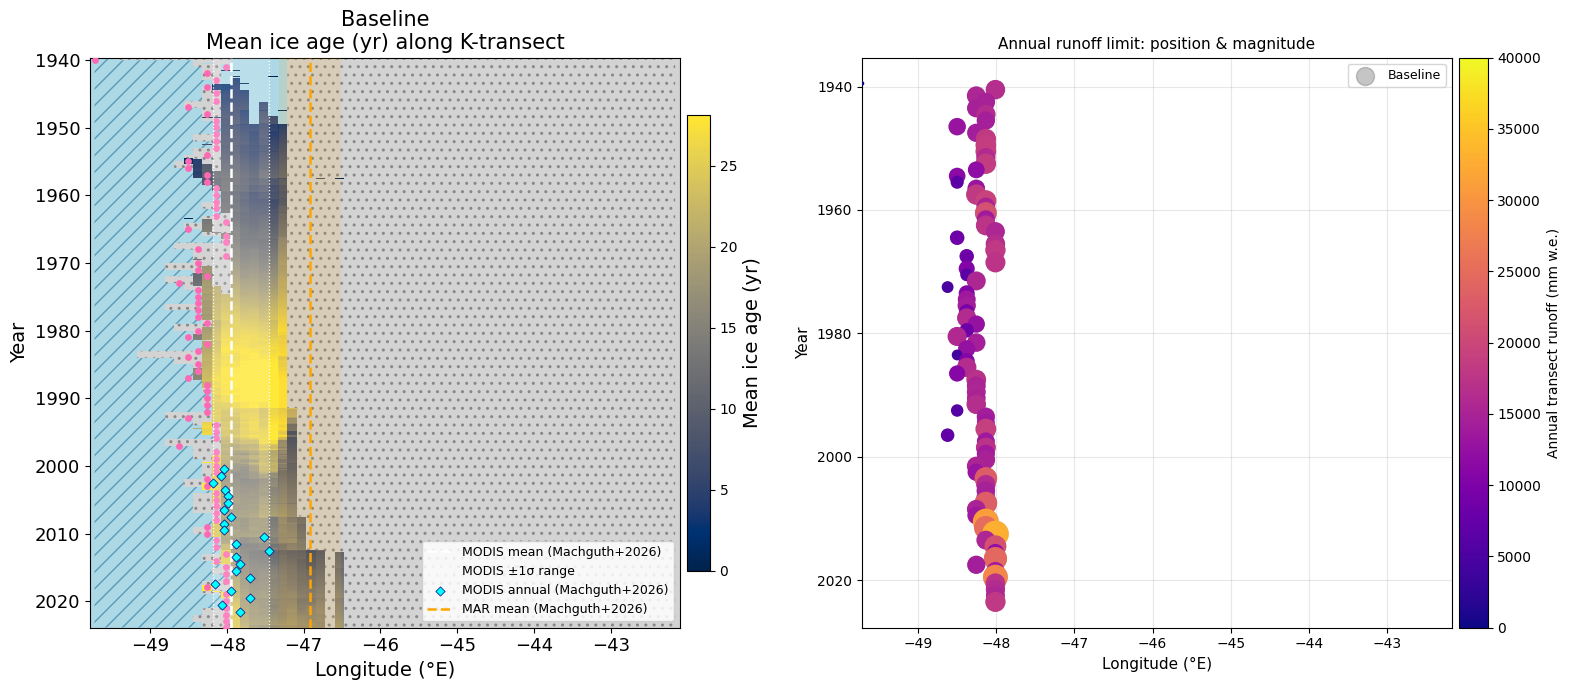

In [73]:
# Expose same variables as load cell so plot cell works without re-loading
hovmoller_ice_plot(ds_baseline, mode='age', ds_baseline=ds_baseline, runoff_vmin=0, runoff_vmax=4e4)

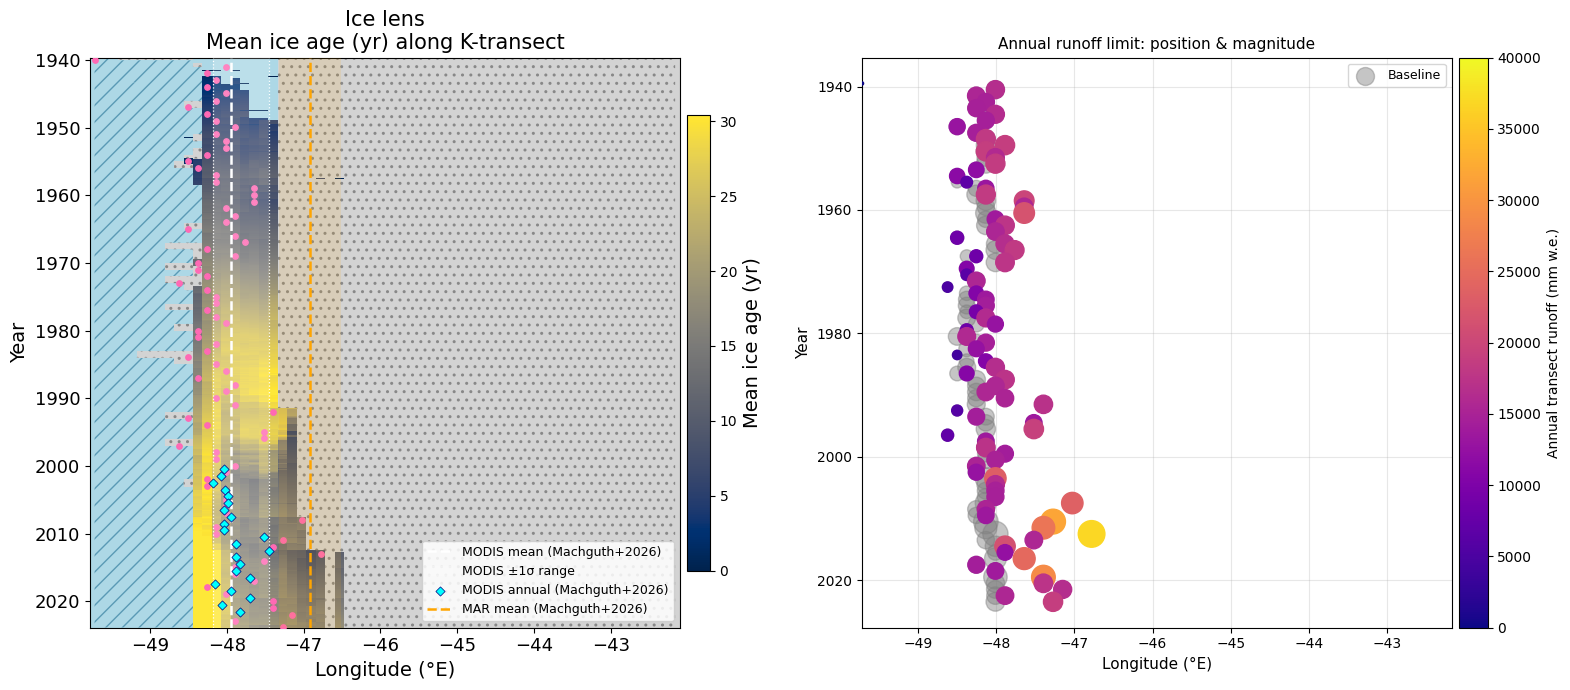

In [74]:
# Expose same variables as load cell so plot cell works without re-loading
hovmoller_ice_plot(ds_icelens, mode='age', ds_baseline=ds_baseline, runoff_vmin=0, runoff_vmax=4e4)


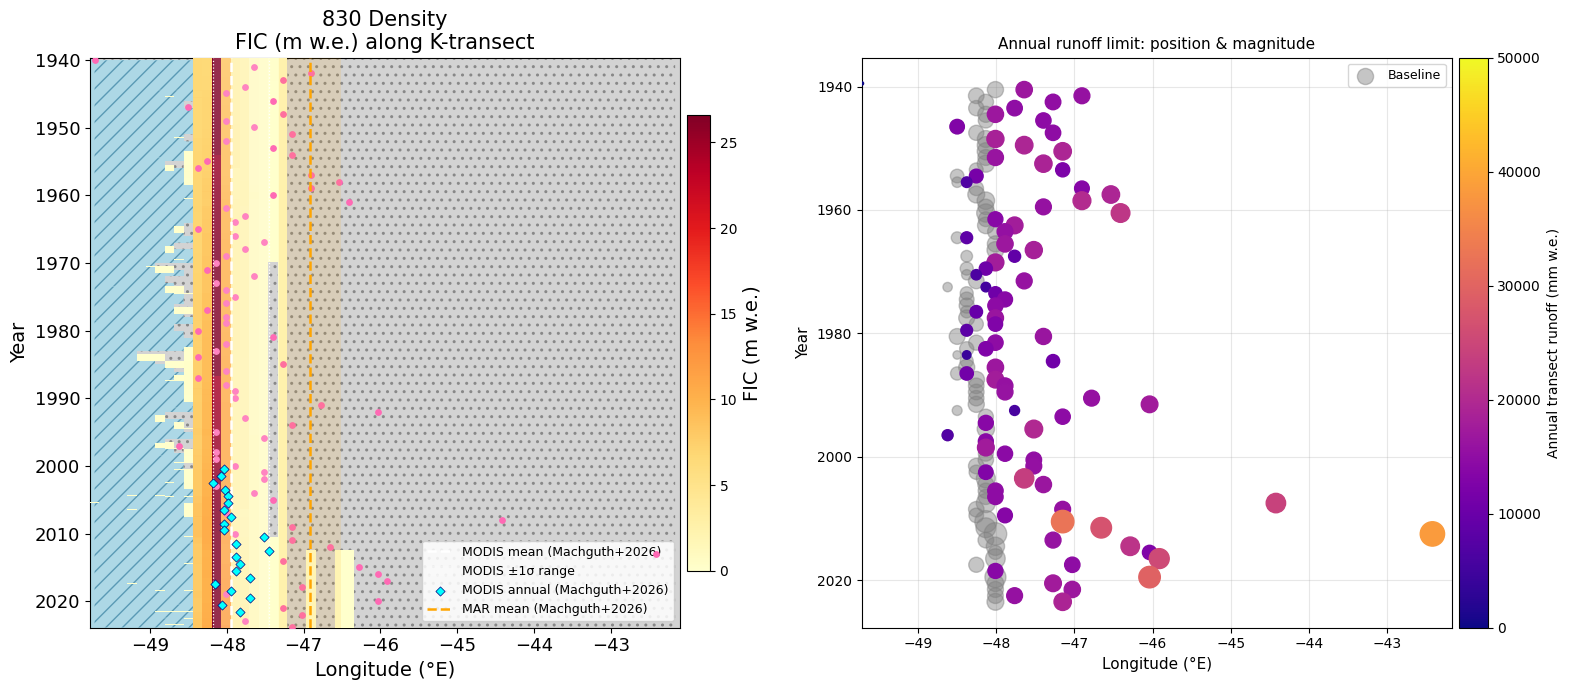

In [76]:
# Expose same variables as load cell so plot cell works without re-loading
hovmoller_ice_plot(ds_dens830, ds_baseline=ds_baseline, runoff_vmin=0, runoff_vmax=5e4)


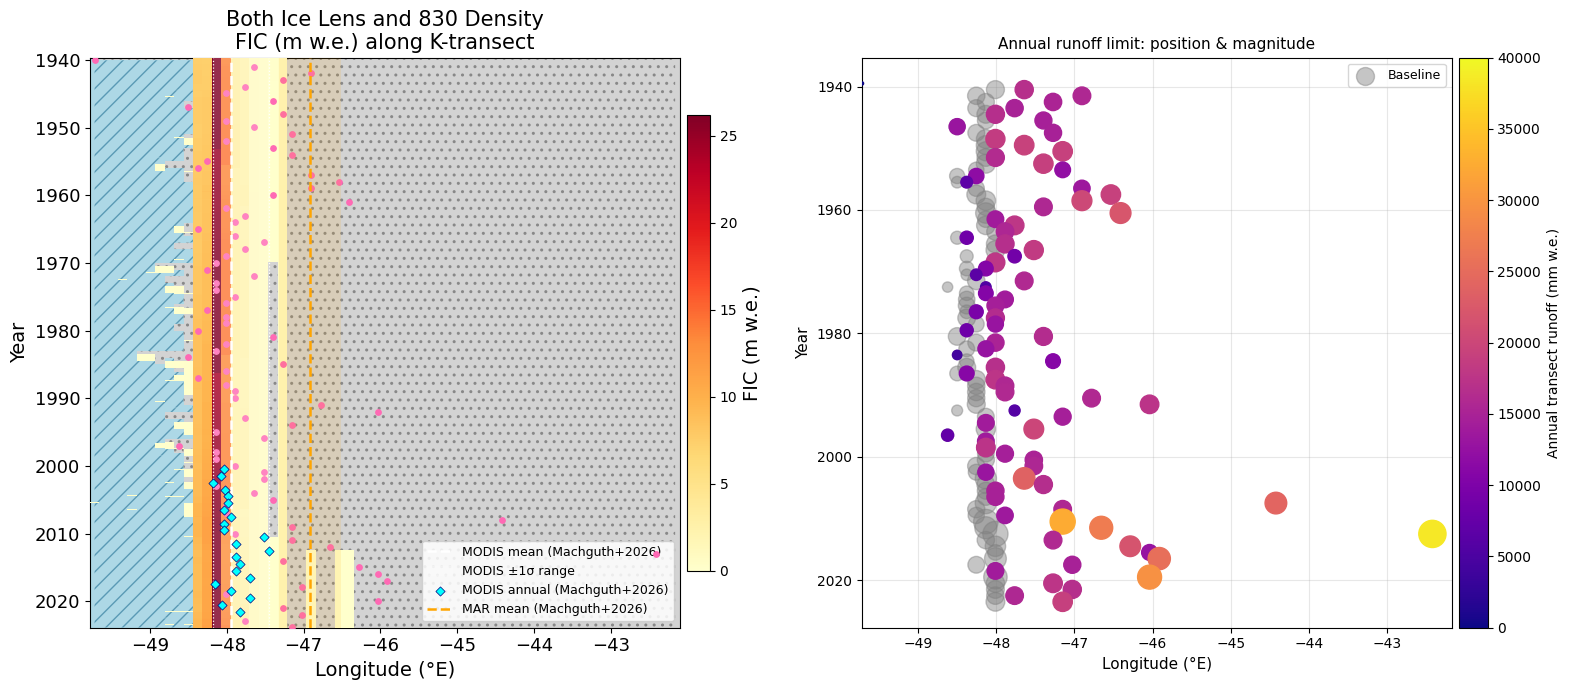

In [81]:
# Expose same variables as load cell so plot cell works without re-loading
hovmoller_ice_plot(ds_both, ds_baseline=ds_baseline, runoff_vmin=0, runoff_vmax=4e4)


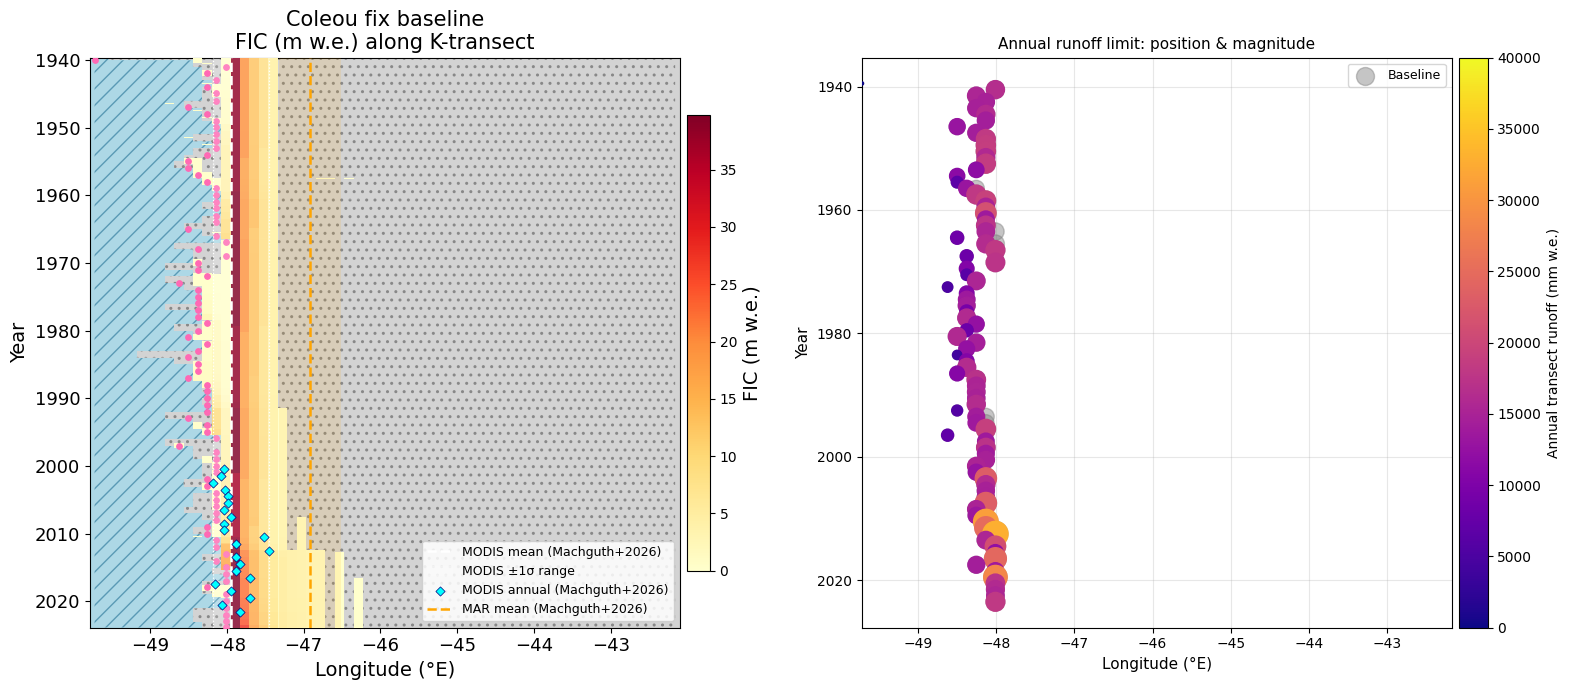

In [82]:
hovmoller_ice_plot(ds_coleou_baseline, ds_baseline=ds_baseline, runoff_vmin=0, runoff_vmax=4e4)

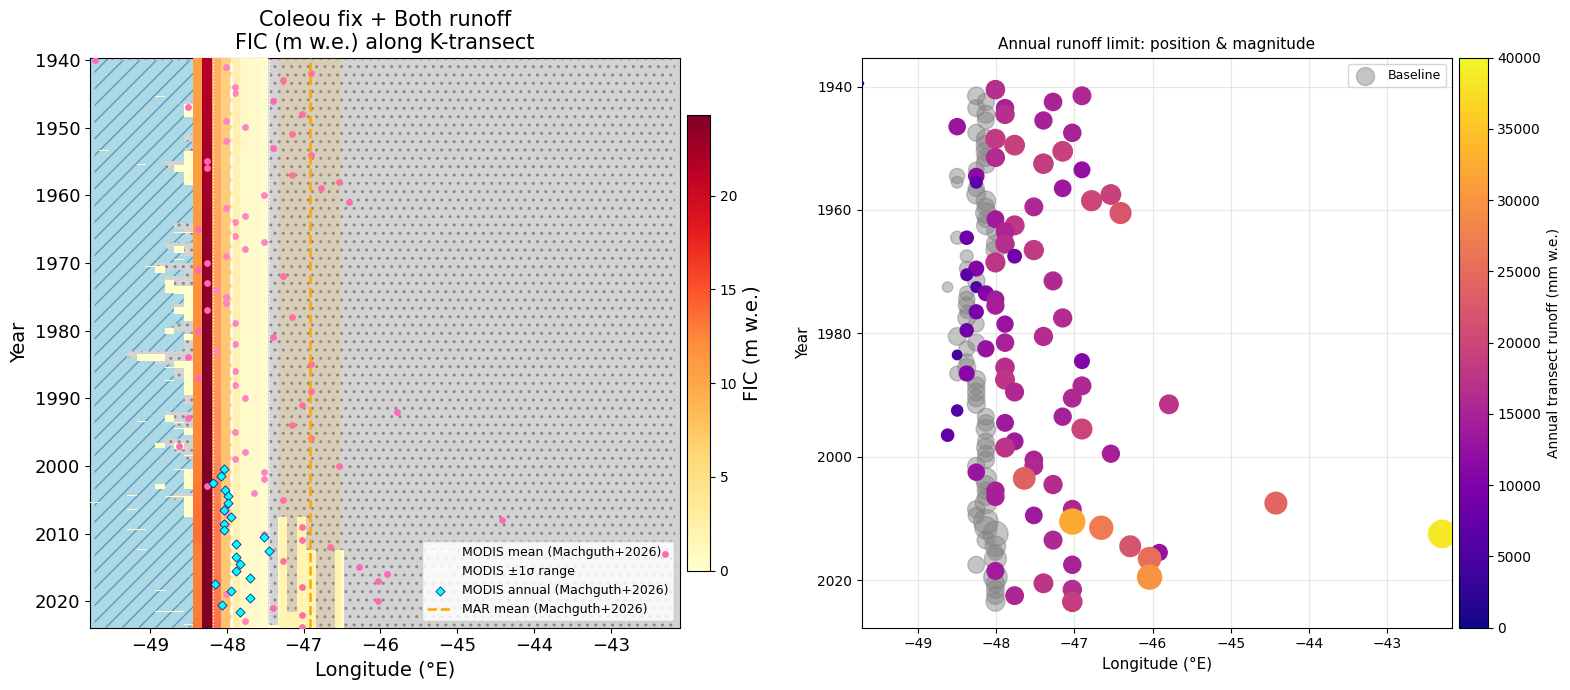

In [83]:
hovmoller_ice_plot(ds_coleou_both, ds_baseline=ds_baseline, runoff_vmin=0, runoff_vmax=4e4)

In [ ]:
hovmoller_four_panel(
    {'Baseline': ds_baseline, 'Ice lens': ds_icelens,
     '830 density': ds_dens830, 'Both': ds_both,
     'Coleou fix + Both': ds_coleau},
    mode='age',
)

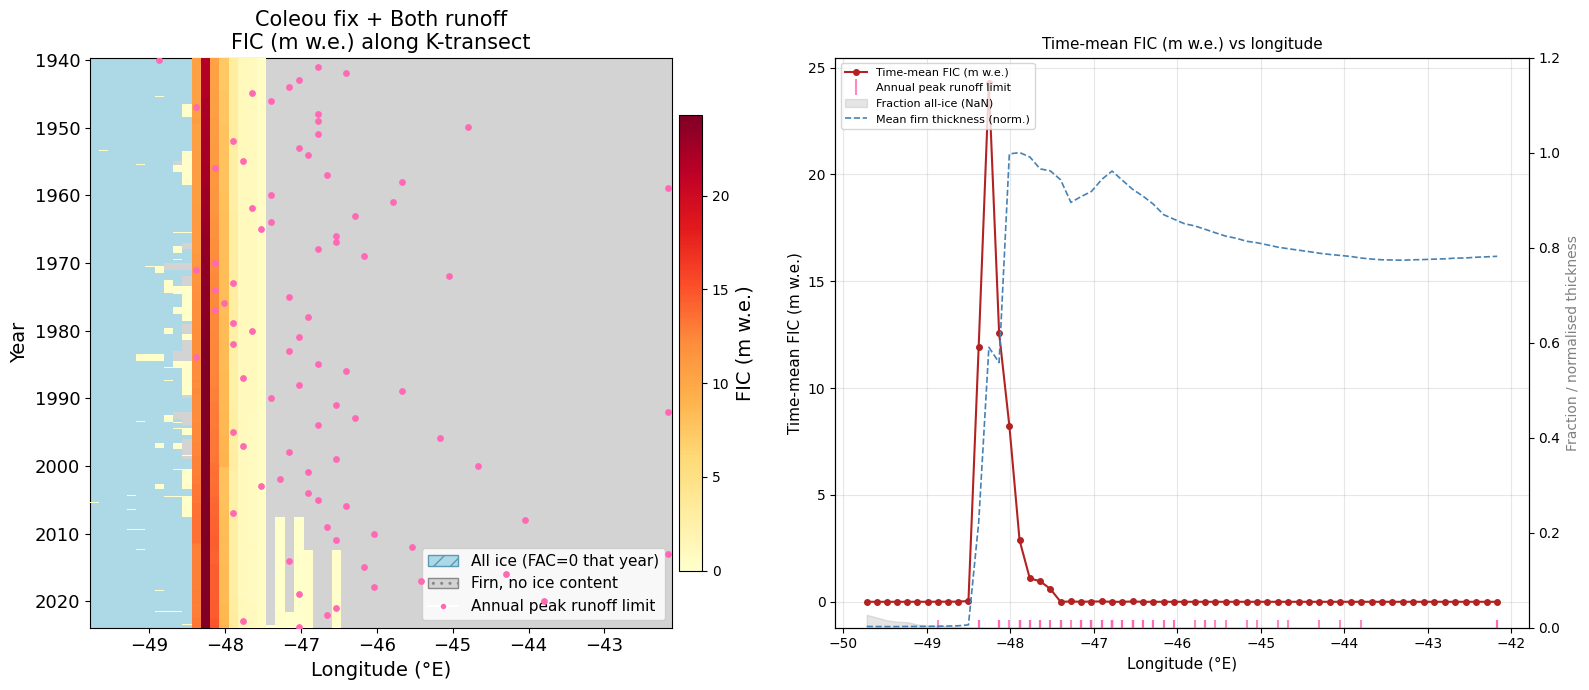

In [ ]:
hovmoller_ice_plot(ds_coleou_)

In [ ]:
import math

def hovmoller_four_panel(datasets, mode='mass', figsize=None, ncols=3):
    """
    Hovmöller panel grid for any number of datasets (originally 4, now N).

    Parameters
    ----------
    datasets : dict  {label: xr.Dataset}
    mode     : 'mass' | 'fraction' | 'age'
    figsize  : tuple or None — auto-computed from ncols/nrows if None
    ncols    : int — number of columns (default 3; use 2 for the original 2×2 layout)
    """
    n     = len(datasets)
    nrows = math.ceil(n / ncols)
    if figsize is None:
        figsize = (ncols * 11, nrows * 8)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes_flat = list(axes.flat) if hasattr(axes, 'flat') else [axes]

    # Hide any unused grid cells
    for i in range(n, nrows * ncols):
        axes_flat[i].set_visible(False)

    for ax, (label, ds) in zip(axes_flat, datasets.items()):
        fic_all  = ds['firn_ice_content'].values
        fth_all  = ds['firn_thickness'].values
        time_arr = ds['time'].values
        rl_lon   = ds['runoff_limit_lon'].values
        lons_ok  = ds['lon'].values

        lon_sort = np.argsort(lons_ok)
        lons_s   = lons_ok[lon_sort]
        fic_s    = (fic_all / 1000.0)[lon_sort]
        fth_s    = fth_all[lon_sort]
        has_ice  = fic_s > 0

        years_int = np.floor(time_arr).astype(int)
        annual_peak_lons, annual_peak_times = [], []
        for yr in np.unique(years_int):
            mask = years_int == yr
            if np.any(np.isfinite(rl_lon[mask])):
                annual_peak_lons.append(np.nanmax(rl_lon[mask]))
                annual_peak_times.append(time_arr[np.where(mask)[0][-1]])

        disp, cbar_label, cmap = _build_disp_var(ds, mode, lon_sort)

        _draw_hovmoller_panel(ax, lons_s, time_arr, fth_s, disp, has_ice,
                              cmap, cbar_label,
                              np.array(annual_peak_lons),
                              np.array(annual_peak_times),
                              title=label, fontsize=16)

        # ── Machguth et al. 2026 reference lines ──────────────────────────
        ref = _MACHGUTH2026
        ax.axvspan(ref['modis_ktransect_min'], ref['modis_ktransect_max'],
                   alpha=0.18, color='white', zorder=8, lw=0)
        ax.axvline(ref['modis_ktransect_mean'], color='white', lw=1.8, ls='--', zorder=9)
        ax.axvline(ref['modis_ktransect_min'],  color='white', lw=0.9, ls=':',  zorder=9)
        ax.axvline(ref['modis_ktransect_max'],  color='white', lw=0.9, ls=':',  zorder=9)
        ax.scatter(ref['annual_lons'],
                   [y + 0.5 for y in ref['annual_years']],
                   s=22, marker='D', color='cyan', edgecolors='navy',
                   linewidths=0.5, zorder=10,
                   label='MODIS annual (Machguth+2026)')
        ax.axvspan(ref['mar_ktransect_min'], ref['mar_ktransect_max'],
                   alpha=0.12, color='orange', zorder=7, lw=0)
        ax.axvline(ref['mar_ktransect_mean'], color='orange', lw=1.8, ls='--', zorder=9,
                   label='MAR mean (Machguth+2026)')

    fig.suptitle(f'Runoff Limit - {cbar_label}', fontsize=20, y=1.01)

    last_ax = axes_flat[n - 1]
    last_ax.plot([], [], color='white', lw=1.8, ls='--', label='MODIS mean (Machguth+2026)')
    last_ax.fill_between([], [], [], alpha=0.3, color='white', label='MODIS mean ± 1σ range')
    last_ax.scatter([], [], s=22, marker='D', color='cyan', edgecolors='navy',
                    linewidths=0.5, label='MODIS annual runoff limit')
    last_ax.legend(loc='lower right', fontsize=10, framealpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
hovmoller_four_panel(
    {'Baseline': ds_baseline, 'Ice lens': ds_icelens,
     '830 density': ds_dens830, 'Both': ds_both,
     'Coleou fix + Both': ds_coleau},
    mode='mass',
)